<a href="https://colab.research.google.com/github/Pen20/LLM_Student_Errors_Prediction/blob/master/predicting_error_types_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import pandas as pd
import io
from google.colab import files
from google.colab import data_table
data_table.enable_dataframe_formatter()
import pandas as pd


In [ ]:
# Import the students data focusing on exclusively on students mistakes
df = pd.read_csv('/content/data_students_errors_topic1.csv')


In [ ]:
%%capture --no-stderr
%pip install -U langgraph langsmith langchain_anthropic

In [ ]:
import getpass
import os


def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")


_set_env("ANTHROPIC_API_KEY")

In [ ]:
!pip install -U langchain langchain-openai

In [ ]:
import os

# Setting environment variables
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_API_KEY"] = "landsith_api_key"
os.environ["LANGSMITH_PROJECT"] = "students_errors_topic1"
os.environ["OPENAI_API_KEY"] = "openai_api_key"


# Using llm ChaGPT

In [ ]:
from langchain_openai import ChatOpenAI

In [ ]:
df_new = df[['student_id', 'response', 'right_answer', 'question', 'seed_id', 'grade']].copy()

In [ ]:
df_new

# The code below generates student mistake responses and stores them in the llm_response column.

In [ ]:
import openai  # Ensure OpenAI library is installed

# Create an OpenAI client (ensure you have set OPENAI_API_KEY in your environment)
client = openai.OpenAI()

# Ensure 'llm_response' column exists
df_new['llm_response'] = ""

# Initialize a list to store responses
llm_responses = []

# Iterate over DataFrame rows dynamically
for i in df_new.index:
    # Extract row data
    data = df_new.loc[i]

    # Construct the message dynamically, providing clarification for special formats
    message = f"""Categorize the types of errors made by the student in mathematics by comparing:
    - Response: {data['response']}
    - Right Answer: {data['right_answer']}

    Additional Context:
    - If the right answer is in the format 'ansa: x, ansb: y', 'ansa' represents the required radius of a circle, while 'ansb' (often 0) indicates sketching requirements.
    - Some right answers use interval notation with specific symbols:
      - cc(a,b) represents the closed interval [a,b].
      - co(a,b) represents the half-open interval [a,b).
      - 'c' stands for a closed boundary, while 'o' stands for an open boundary.

    When analyzing the student's response, ensure you interpret these special formats correctly. Clearly identify the specific type of error the student made, whether it is a misinterpretation of notation, an incorrect numerical value, or a conceptual misunderstanding.
    """

    # Invoke the LLM using GPT-4o
    response = client.chat.completions.create(
        model="gpt-4o",  # Explicitly specifying GPT-4o model
        messages=[{"role": "user", "content": message}]
    )

    # Extract content from OpenAI response (latest API format)
    llm_response_text = response.choices[0].message.content.strip()

    # Remove unwanted symbols (in case of any formatting artifacts)
    llm_response_text = llm_response_text.replace("**", "").replace("*", "")

    # Append response to list
    llm_responses.append(llm_response_text)

# Assign responses to DataFrame in one step (efficient)
df_new['llm_response'] = llm_responses

# Display the updated DataFrame
df_new

# The code below generates a non-redundant list of error types extracted from each question variant to ensure clarity and avoid repetition, then stores the result in the error_summary column.

In [ ]:
# Ensure 'error_summary' column exists
df_new['error_summary'] = ""

# Initialize a list to store extracted errors for each row
error_summaries = []

# Iterate over each row in the DataFrame
for i, row in df_new.iterrows():
    llm_response = row['llm_response']  # Get the LLM-generated analysis

    # Skip if response is missing
    if pd.isna(llm_response) or llm_response.strip() == "":
        error_summaries.append("")
        continue

    # Construct the prompt dynamically for GPT-4o to extract error types
    message = f"""You will extract and categorize only the actual mathematical errors made by a student based on the provided analysis.

### **Instructions:**
1. Read the analysis of the student's response carefully.
2. Identify distinct **error types** involving mathematical reasoning, values, interpretation, or expression.
3. Categorize these errors meaningfully using concise labels such as:
   - omission error
   - incorrect response
   - notational/formatting error
   - conceptual misunderstanding
   - misinterpretation of notation
   - incorrect numerical value
   - procedural or calculation error
4. **Only list actual errors**. If no errors are found in the response, do not return anything.
5. Do **not** include duplicates.
6. Do **not** include explanations or surrounding text.
7. Remove any unwanted formatting symbols (e.g., `*`, `**`).

### **Expected Output Format:**
A clean, comma-separated list of unique error types.
**Example:**
omission error, conceptual misunderstanding, incorrect numerical value

### **Input (LLM Response):**
{llm_response}

Now extract and return only the unique categorized mathematical error types found in the response.
"""

    # Invoke the LLM using GPT-4o
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[{"role": "user", "content": message}]
    )

    # Extract and clean the categorized error types
    extracted_errors = response.choices[0].message.content.strip()
    extracted_errors = extracted_errors.replace("*", "").replace("**", "").strip()

    # Append to list
    error_summaries.append(extracted_errors)

# Assign the extracted error summaries to the DataFrame
df_new['error_summary'] = error_summaries

# Display the updated DataFrame
df_new


# Finally, the code below completes the following task: it maps the extracted error types to Newman’s Error Analysis (NEA) framework, which classifies mistakes into five cognitive categories—reading, comprehension, transformation, process skills, and encoding. The results are stored in the error_category column.

In [ ]:
# Ensure 'error_category' column exists
df_new['error_category'] = ""

# Initialize a list to store extracted errors for each row
error_categories = []

# Iterate over each row in the DataFrame
for i, row in df_new.iterrows():
    llm_response = row['llm_response']  # Get the LLM-generated analysis

    # Skip if response is missing
    if pd.isna(llm_response) or llm_response.strip() == "":
        error_categories.append("")
        continue

    # Construct the prompt dynamically for GPT-4o to extract error types
    message = f"""You will analyze the student's response analysis and categorize any mathematical mistakes using **Newman’s Error Analysis framework**.

### **Instructions:**
1. Carefully read the provided analysis of the student's response.
2. Identify the specific types of errors that align with **Newman's five error categories**:
   - Reading Errors
   - Comprehension Errors
   - Transformation Errors
   - Process Skill Errors
   - Encoding Errors
3. Only include categories that are clearly evident in the analysis.
4. Do **not** list categories that are not relevant or applicable.
5. Do **not repeat** any category — each error type must appear only once.
6. Do **not include** explanations, justifications, or extra text.
7. Remove any unwanted formatting symbols (e.g., `*`, `**`) in the output.
8. Present the final answer as a **clean, comma-separated list** of unique error categories.

### **Expected Output Format:**
encoding errors, comprehension errors, transformation errors

### **Input (LLM Response):**
{llm_response}

Now return only the categorized error types according to Newman's framework.
"""

    # Invoke the LLM using GPT-4o
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[{"role": "user", "content": message}]
    )

    # Extract and clean the categorized error types
    extracted_errors = response.choices[0].message.content.strip()
    extracted_errors = extracted_errors.replace("*", "").replace("**", "").strip()

    # Append to list
    error_categories.append(extracted_errors)

# Assign the extracted error categories to a new column in the DataFrame
df_new['error_category'] = error_categories

# Display the updated DataFrame
df_new


# Refer to Appendix B to access the Excel file containing predictions of student errors.
https://docs.google.com/spreadsheets/d/1cs2Ti59Oo7sBowpL818h1ghGTYZ4BYlD7wVBLvUamhQ/edit?usp=sharing

# Data analysis

In [ ]:
# Load the  dataset
import pandas as pd

df = pd.read_csv('/content/df_predicting_students_errors.csv')
df

,student_id,response,right_answer,question,seed_id,grade,llm_response,error_summary,error_category
0,1,"ans1: x^2+y^2=4 ans2: ""Point"" ans3: ""Circle""","ans1: y^2+x^2 = 4 ans2: ""Point"" ans3: ""Circl...",Q. 1,854304650,0.60,Based on the provided response and the right a...,omission error,"comprehension errors, encoding errors"
1,1,"ans1: y=18*t^2+9*t-1 ans2: ""Point"" ans3: ""Pa...","ans1: y = 2*x^2+3*x-1 ans2: ""Point"" ans3: ""P...",Q. 2,1225488973,0.40,To categorize the types of errors made by the ...,"misinterpretation of notation, incorrect numer...","comprehension errors, transformation errors, e..."
2,1,ans1: t/3 ans2: 3*t^2 ans3: 0 ans4: 5*sin(t...,ans1: t/3 ans2: 3*t^2 ans3: 0 ans4: 5*sin(t...,Q. 3,1509813580,0.75,Based on the comparison between the student's ...,incorrect numerical value,transformation errors
3,1,ans1: y=-8/5-8/5,ans1: y = -((8*x)/5)-8/5,Q. 4,163677917,0.00,"To analyze the student's error in mathematics,...","omission error, conceptual misunderstanding","comprehension errors, transformation errors"
4,1,"ans1: 2/(4*t^2-3*t-4) ans2: [t=2,t=-1,t=0] a...","ans1: (2*t)/(4*t^3-3*t^2-4*t) ans2: [t = 2,t ...",Q. 5,1500539490,0.57,The student's errors can be categorized as fol...,misinterpretation or incorrect transcription o...,"comprehension errors, transformation errors, e..."
...,...,...,...,...,...,...,...,...,...
2826,618,"ans1: x^2+y^2=1 ans2: ""Point"" ans3: ""Circle""...","ans1: y^2+x^2 = 1 ans2: ""Point"" ans3: ""Circl...",Q. 1,1504181159,0.80,Based on the comparison between the student's ...,omission error,encoding errors
2827,618,"ans1: y=-4*x^2-5*x ans2: ""Point"" ans3: ""Para...","ans1: y = -x^2-5*x+4 ans2: ""Point"" ans3: ""Pa...",Q. 2,141996950,0.40,To categorize the types of errors made by the ...,"incorrect numerical coefficient, omission erro...","transformation errors, process skill errors, c..."
2828,618,"ans1: t ans2: 3*t^2 ans3: ""cos^3*(theta)"" a...",ans1: t ans2: 3*t^2 ans3: cos(theta)^3 ans4: 0,Q. 3,896417394,0.75,Based on the information provided for the comp...,misinterpretation of notation,encoding errors
2829,618,"ans1: (2*t)/(5*t^4-8*t^3-9*t^3) ans2: [t=0,t=...","ans1: (2*t)/(5*t^4-8*t^3-9*t^2) ans2: [t = 3,...",Q. 5,353452773,0.14,Let's analyze the student's responses compared...,"misinterpretation of notation, incorrect numer...","comprehension errors, transformation errors, p..."


# Task 1: Question analysis for using both difficulty index and discrimination index:


In [ ]:
# Re-import necessary libraries after environment reset
import pandas as pd
import numpy as np

# Reload the dataset
file_path = '/content/df_predicting_students_errors.csv'
df = pd.read_csv(file_path)

# -------------------------------
# Difficulty Index Calculation
# -------------------------------
# Filter questions of interest
questions_of_interest = [f"Q. {i}" for i in range(1, 7)]
filtered_df = df[df["question"].isin(questions_of_interest)]

# Group by question and compute difficulty index
difficulty_indices = (
    filtered_df.groupby("question")["grade"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "sum_fx", "count": "n"})
)

# Apply the difficulty index formula
X_max, X_min = 1, 0
difficulty_indices["difficulty_index"] = difficulty_indices["sum_fx"] / (
    difficulty_indices["n"] * (X_max - X_min)
)
difficulty_indices = difficulty_indices.reset_index()

# -------------------------------
# Discrimination Index Calculation
# -------------------------------
# Step 1: Compute total grade per student
total_grade_per_student = df.groupby("student_id")["grade"].sum().reset_index()
total_grade_per_student = total_grade_per_student.sort_values(by="grade", ascending=False)

# Step 2: Define upper and lower 27% groups
n_students = len(total_grade_per_student)
group_size = int(np.ceil(n_students * 0.27))

upper_group_ids = total_grade_per_student.head(group_size)["student_id"]
lower_group_ids = total_grade_per_student.tail(group_size)["student_id"]

# Step 3: Define discrimination index function
def discrimination_index(q_df):
    up = q_df[q_df["student_id"].isin(upper_group_ids) & (q_df["grade"] > 0)].shape[0]
    lp = q_df[q_df["student_id"].isin(lower_group_ids) & (q_df["grade"] > 0)].shape[0]
    return (up - lp) / group_size

# Step 4: Compute discrimination index for each question
discrimination_results = (
    filtered_df.groupby("question")
    .apply(discrimination_index)
    .reset_index(name="discrimination_index")
)

# Merge difficulty and discrimination results
analysis_results = pd.merge(difficulty_indices, discrimination_results, on="question")

# Display results
analysis_results.drop(columns=['sum_fx', 'n'], inplace=True)
analysis_results


<ipython-input-106-587d90e9cc55>:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(discrimination_index)


,question,difficulty_index,discrimination_index
0,Q. 1,0.732331,0.323353
1,Q. 2,0.576812,0.287425
2,Q. 3,0.543046,0.520958
3,Q. 4,0.000000,0.000000
4,Q. 5,0.579881,0.149701
5,Q. 6,0.568510,0.167665


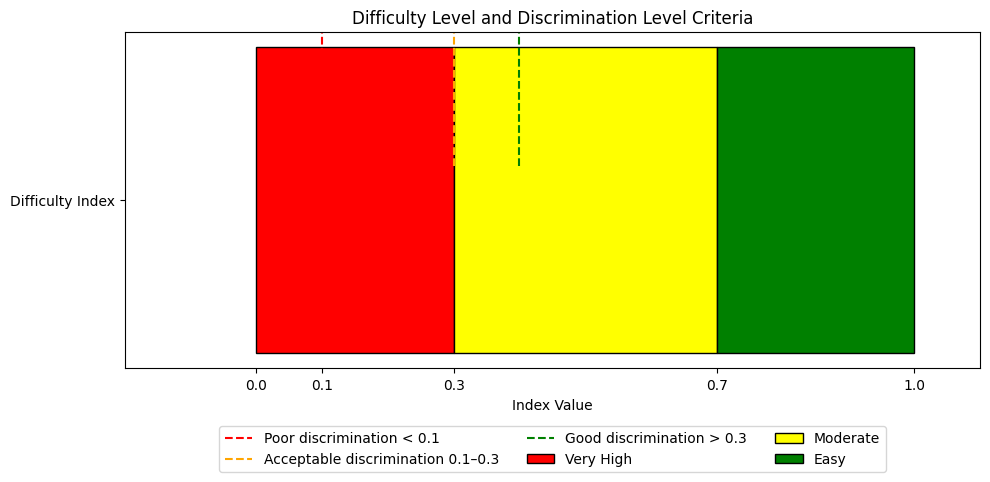

In [ ]:
import matplotlib.pyplot as plt

# Create a summary chart for Difficulty Index and Discrimination Index criteria
fig, ax = plt.subplots(figsize=(10, 5))

# Draw difficulty index regions as horizontal bars
difficulty_levels = ["Very High", "Moderate", "Easy"]
difficulty_bounds = [0.0, 0.3, 0.7, 1.0]
colors = ["red", "yellow", "green"]

for i in range(3):
    ax.barh(y="Difficulty Index", width=difficulty_bounds[i+1] - difficulty_bounds[i],
            left=difficulty_bounds[i], height=0.4, color=colors[i], edgecolor='black', label=difficulty_levels[i])

# Draw discrimination index threshold lines
ax.axvline(x=0.1, ymin=0.6, ymax=1.0, color="red", linestyle="--", label="Poor discrimination < 0.1")
ax.axvline(x=0.3, ymin=0.6, ymax=1.0, color="orange", linestyle="--", label="Acceptable discrimination 0.1–0.3")
ax.axvline(x=0.4, ymin=0.6, ymax=1.0, color="green", linestyle="--", label="Good discrimination > 0.3")

# Formatting
ax.set_xlim(-0.2, 1.1)
ax.set_yticks(["Difficulty Index"])
ax.set_xticks([0.0, 0.1, 0.3, 0.7, 1.0])
ax.set_xlabel("Index Value")
ax.set_title("Difficulty Level and Discrimination Level Criteria")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)

plt.tight_layout()
plt.show()


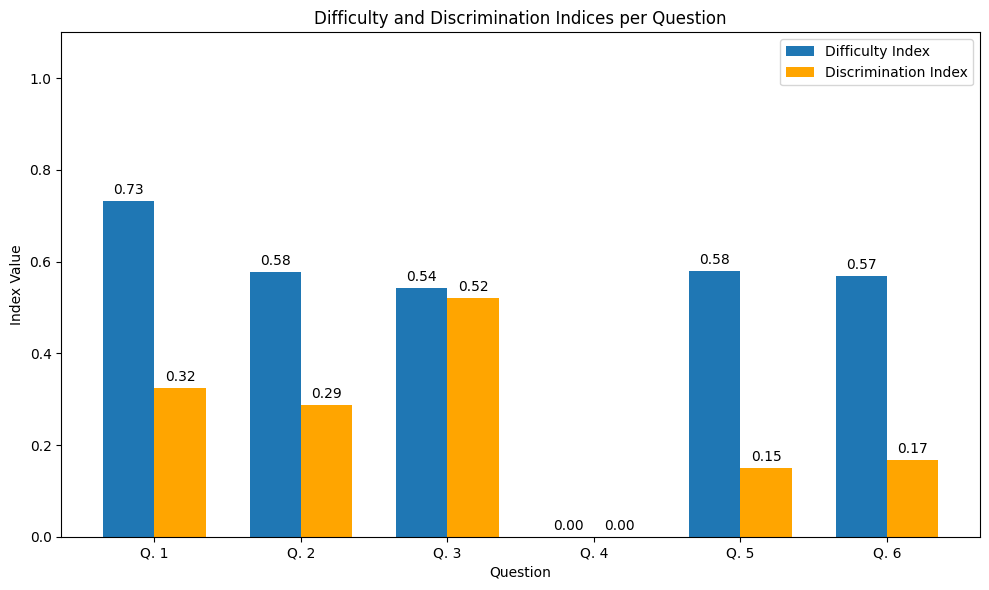

In [ ]:
import matplotlib.pyplot as plt

# Create bar chart for Difficulty and Discrimination Index side-by-side
fig, ax1 = plt.subplots(figsize=(10, 6))

bar_width = 0.35
x = np.arange(len(analysis_results["question"]))

# Bars for Difficulty Index
bars1 = ax1.bar(x - bar_width/2, analysis_results["difficulty_index"],
                width=bar_width, label='Difficulty Index')

# Bars for Discrimination Index
bars2 = ax1.bar(x + bar_width/2, analysis_results["discrimination_index"],
                width=bar_width, label='Discrimination Index', color='orange')

# Formatting
ax1.set_xlabel('Question')
ax1.set_ylabel('Index Value')
ax1.set_title('Difficulty and Discrimination Indices per Question')
ax1.set_xticks(x)
ax1.set_xticklabels(analysis_results["question"])
ax1.set_ylim(0, 1.1)
ax1.legend()

# Annotate bars with values
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.2f}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom')

plt.tight_layout()
plt.show()


# Calculate the percentage of entries in the dataset that contain each of the following errors:

Reading errors

Comprehension errors

Transformation errors

Process skill errors

Encoding errors

In [ ]:
# Define the target error types
error_types = [
    "reading errors",
    "comprehension errors",
    "transformation errors",
    "process skill errors",
    "encoding errors"
]

# Normalize the error_category column (lowercase, no NaNs)
df['error_category'] = df['error_category'].fillna('').str.lower()

# Count the presence of each error type in the dataset
total_entries = len(df)
error_counts = {
    error: df['error_category'].str.contains(error).sum()
    for error in error_types
}

# Calculate percentages
error_percentages = {
    error: (count / total_entries) * 100
    for error, count in error_counts.items()
}

# Convert to DataFrame for easier display
error_percentages_df = pd.DataFrame.from_dict(
    error_percentages, orient='index', columns=['Percentage']
).sort_values(by='Percentage', ascending=False)

# Round percentages to 2 decimal places
error_percentages_rounded_df = error_percentages_df.round(2)

# Display the updated table
error_percentages_rounded_df


,Percentage
transformation errors,67.36
comprehension errors,59.84
encoding errors,37.48
process skill errors,28.15
reading errors,1.17


# Most Common Mistakes in Question Q4

In [ ]:
# Filter the data for Question 4
q4_df = df[df["question"] == "Q. 4"]

# Drop missing error summaries
q4_errors = q4_df["error_summary"].dropna()

# Split error summaries into individual error types and count them
from collections import Counter

# Split each error summary into components and flatten the list
error_types = q4_errors.str.split(", ").explode()
error_counts = Counter(error_types)

# Convert to DataFrame for display
error_summary_df = pd.DataFrame(error_counts.items(), columns=["Error Type", "Frequency"])
error_summary_df = error_summary_df.sort_values(by="Frequency", ascending=False).reset_index(drop=True)



# Calculate total number of error instances for Q4
total_errors_q4 = error_summary_df["Frequency"].sum()

# Add percentage column
error_summary_df["Percentage"] = (error_summary_df["Frequency"] / total_errors_q4 * 100).round(2)

error_summary_df



,Error Type,Frequency,Percentage
0,incorrect numerical value,95,42.04
1,conceptual misunderstanding,63,27.88
2,misinterpretation of notation,17,7.52
3,sign error,10,4.42
4,omission error,7,3.10
5,notational/formatting error,6,2.65
6,procedural or calculation error,5,2.21
7,incorrect response,2,0.88
8,structural misinterpretation,1,0.44
9,misrepresentation of variables,1,0.44


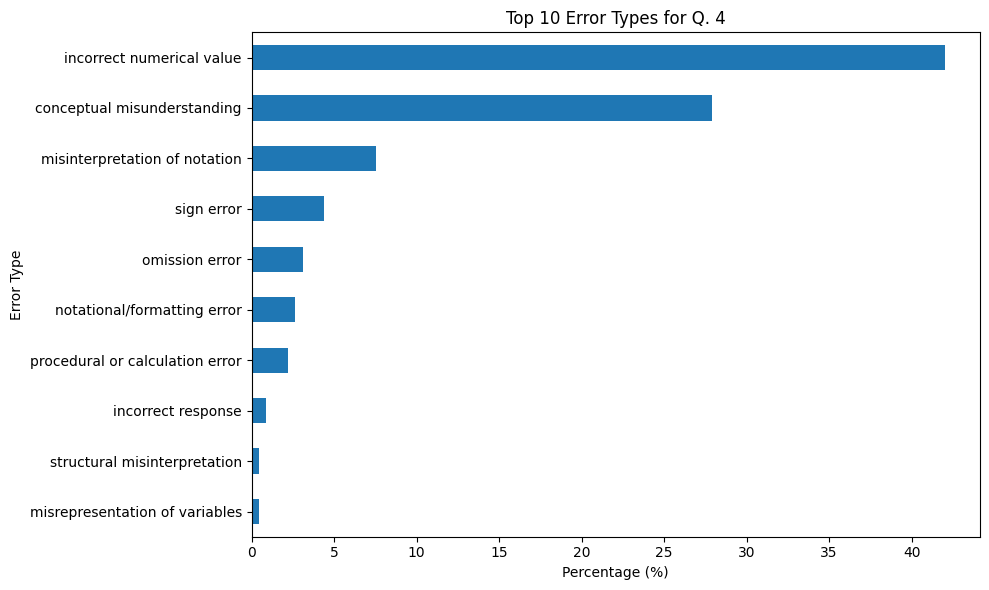

In [ ]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# ---- PARAMETERS ----
question = "Q. 4"      # which question to filter on
top_n = 10             # change this to any number you like

# ---- DATA PREP ----
errors = (
    df[df["question"] == question]
      ["error_summary"]
      .dropna()
      .str.split(", ")
      .explode()
)
counts = Counter(errors)
summary_df = (
    pd.DataFrame(counts.items(), columns=["Error Type", "Frequency"])
      .sort_values(by="Frequency", ascending=False)
      .reset_index(drop=True)
)
total = summary_df["Frequency"].sum()
summary_df["Percentage"] = (summary_df["Frequency"] / total * 100).round(2)

# ---- SELECT TOP N ----
top_df = summary_df.head(top_n)

# ---- PLOTTING ----
ax = top_df.plot(
    kind='barh',
    x='Error Type',
    y='Percentage',
    legend=False,
    figsize=(10, 6)
)
ax.invert_yaxis()  # largest at top
ax.set_xlabel("Percentage (%)")
ax.set_ylabel("Error Type")
ax.set_title(f"Top {len(top_df)} Error Types for {question}")
plt.tight_layout()
plt.show()


In [ ]:
# Filter for Question 4 and drop missing error categories
q4_error_cat = df[df["question"] == "Q. 4"]["error_category"].dropna()

# Split and count error categories
error_cat_types = q4_error_cat.str.split(", ").explode()
error_cat_counts = Counter(error_cat_types)

# Convert to DataFrame and calculate percentages
error_cat_df = pd.DataFrame(error_cat_counts.items(), columns=["Error Category", "Frequency"])
error_cat_df = error_cat_df.sort_values(by="Frequency", ascending=False).reset_index(drop=True)
total_cat_errors = error_cat_df["Frequency"].sum()
error_cat_df["Percentage"] = (error_cat_df["Frequency"] / total_cat_errors * 100).round(2)
error_cat_df

,Error Category,Frequency,Percentage
0,transformation errors,94,41.96
1,comprehension errors,44,19.64
2,encoding errors,43,19.20
3,process skill errors,43,19.20


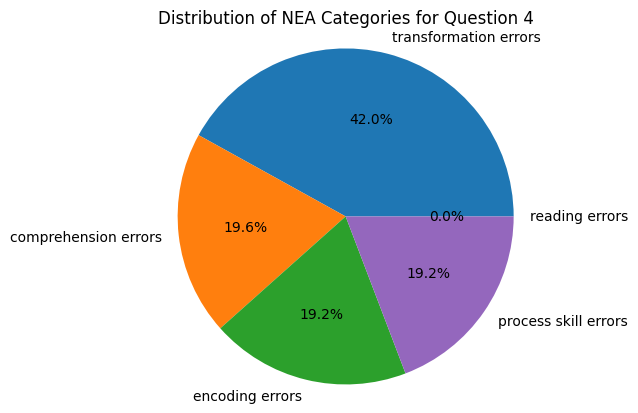

In [ ]:
top_cat_df = error_cat_df
others_pct = 100 - top_cat_df["Percentage"].sum()
labels = list(top_cat_df["Error Category"]) + ["reading errors"]
sizes = list(top_cat_df["Percentage"]) + [others_pct]

# Define colors excluding red
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']

# Plot pie chart without red
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors)
ax.axis('equal')
plt.title('Distribution of NEA Categories for Question 4')
plt.show()

# Most common errors for Question 3

In [ ]:
# Filter for Question 3 and drop missing error summaries
q3_errors = df[df["question"] == "Q. 3"]["error_summary"].dropna()

# Split and count individual error types
q3_error_types = q3_errors.str.split(", ").explode()
q3_error_counts = Counter(q3_error_types)

# Create DataFrame and calculate percentages
q3_error_df = pd.DataFrame(q3_error_counts.items(), columns=["Error Type", "Frequency"])
q3_error_df = q3_error_df.sort_values(by="Frequency", ascending=False).reset_index(drop=True)
total_q3_errors = q3_error_df["Frequency"].sum()
q3_error_df["Percentage"] = (q3_error_df["Frequency"] / total_q3_errors * 100).round(2)

q3_error_df

,Error Type,Frequency,Percentage
0,incorrect numerical value,314,44.23
1,conceptual misunderstanding,171,24.08
2,misinterpretation of notation,44,6.20
3,sign error,42,5.92
4,incorrect response,34,4.79
5,omission error,16,2.25
6,incorrect numerical coefficient,16,2.25
7,incorrect numerical sign,10,1.41
8,incorrect sign,9,1.27
9,notational/formatting error,4,0.56


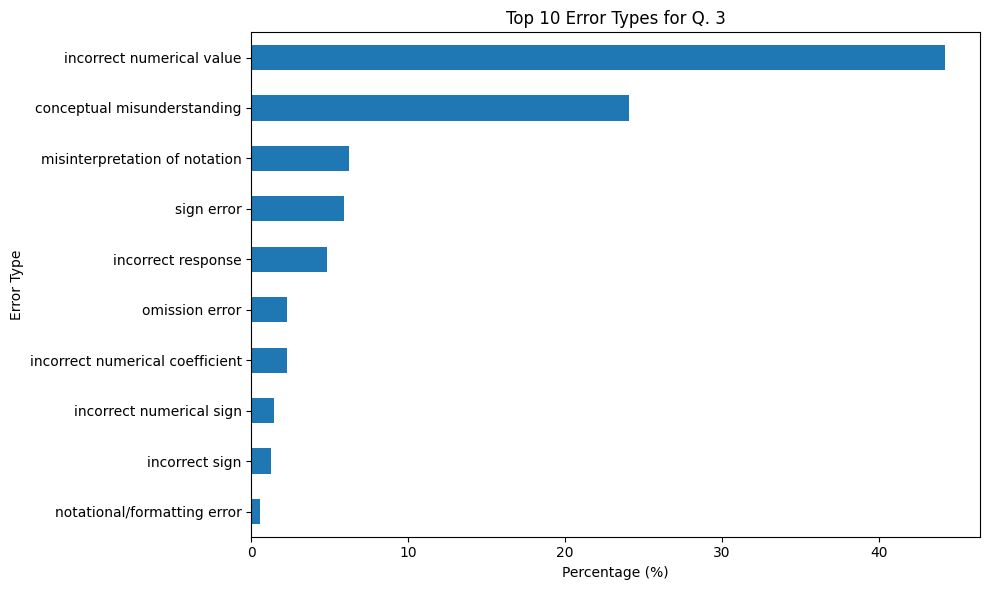

In [ ]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# ---- PARAMETERS ----
question = "Q. 3"      # which question to filter on
top_n = 10             # change this to any number you like

# ---- DATA PREP ----
errors = (
    df[df["question"] == question]
      ["error_summary"]
      .dropna()
      .str.split(", ")
      .explode()
)
counts = Counter(errors)
summary_df = (
    pd.DataFrame(counts.items(), columns=["Error Type", "Frequency"])
      .sort_values(by="Frequency", ascending=False)
      .reset_index(drop=True)
)
total = summary_df["Frequency"].sum()
summary_df["Percentage"] = (summary_df["Frequency"] / total * 100).round(2)

# ---- SELECT TOP N ----
top_df = summary_df.head(top_n)

# ---- PLOTTING ----
ax = top_df.plot(
    kind='barh',
    x='Error Type',
    y='Percentage',
    legend=False,
    figsize=(10, 6)
)
ax.invert_yaxis()  # largest at top
ax.set_xlabel("Percentage (%)")
ax.set_ylabel("Error Type")
ax.set_title(f"Top {len(top_df)} Error Types for {question}")
plt.tight_layout()
plt.show()


In [ ]:
# Filter for Question 3 and drop missing error categories
q3_error_cat = df[df["question"] == "Q. 3"]["error_category"].dropna()

# Split and count error categories
q3_error_cat_types = q3_error_cat.str.split(", ").explode()
q3_error_cat_counts = Counter(q3_error_cat_types)

# Create DataFrame and calculate percentages
q3_error_cat_df = pd.DataFrame(q3_error_cat_counts.items(), columns=["Error Category", "Frequency"])
q3_error_cat_df = q3_error_cat_df.sort_values(by="Frequency", ascending=False).reset_index(drop=True)
total_q3_cat_errors = q3_error_cat_df["Frequency"].sum()
q3_error_cat_df["Percentage"] = (q3_error_cat_df["Frequency"] / total_q3_cat_errors * 100).round(2)

q3_error_cat_df

,Error Category,Frequency,Percentage
0,transformation errors,326,48.22
1,encoding errors,122,18.05
2,comprehension errors,119,17.60
3,process skill errors,107,15.83
4,reading errors,2,0.30


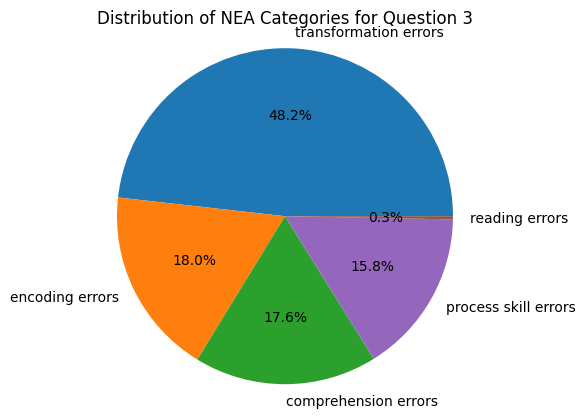

In [ ]:
# Prepare top 5 categories and group others
top_n = 4
top_cat_df = q3_error_cat_df.head(top_n)
others_pct = 100 - top_cat_df["Percentage"].sum()
labels = list(top_cat_df["Error Category"]) + ["reading errors"]
sizes = list(top_cat_df["Percentage"]) + [others_pct]

# Define colors excluding red
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']

# Plot pie chart
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors)
ax.axis('equal')
plt.title('Distribution of NEA Categories for Question 3')
plt.show()

# Most common errors for question 5

In [ ]:
# Filter for Question 5 and drop missing error summaries
q5_errors = df[df["question"] == "Q. 5"]["error_summary"].dropna()

# Split and count individual error types
q5_error_types = q5_errors.str.split(", ").explode()
q5_error_counts = Counter(q5_error_types)

# Create DataFrame and calculate percentages
q5_error_df = pd.DataFrame(q5_error_counts.items(), columns=["Error Type", "Frequency"])
q5_error_df = q5_error_df.sort_values(by="Frequency", ascending=False).reset_index(drop=True)
total_q5_errors = q5_error_df["Frequency"].sum()
q5_error_df["Percentage"] = (q5_error_df["Frequency"] / total_q5_errors * 100).round(2)

q5_error_df

,Error Type,Frequency,Percentage
0,incorrect numerical value,476,28.50
1,conceptual misunderstanding,335,20.06
2,misinterpretation of notation,331,19.82
3,notational/formatting error,68,4.07
4,omission error,26,1.56
...,...,...,...
218,conceptual/format error,1,0.06
219,incorrect formulation of equation,1,0.06
220,misinterpretation or incorrect manipulation of...,1,0.06
221,logical/comprehension error,1,0.06


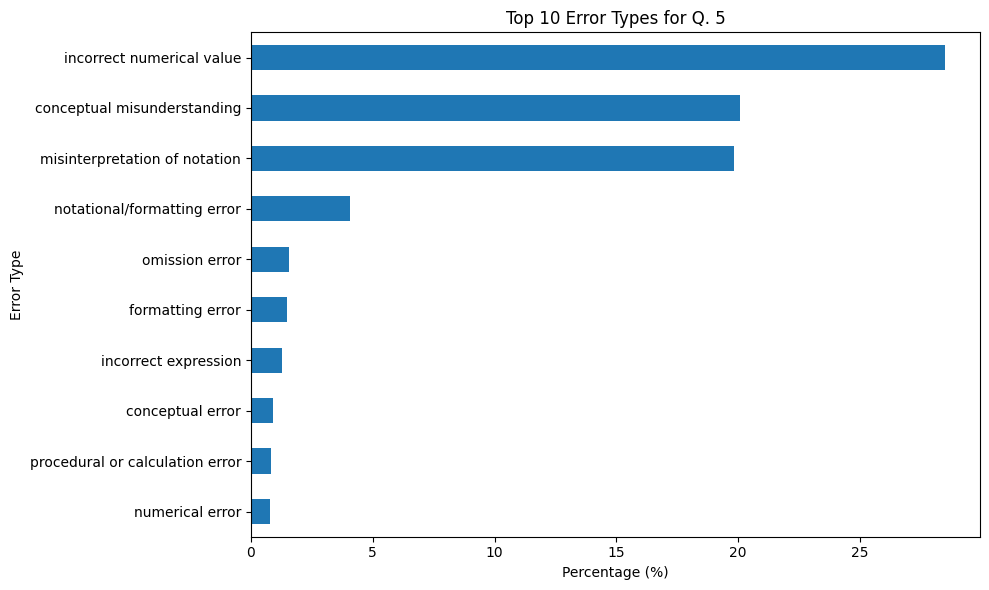

In [ ]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# ---- PARAMETERS ----
question = "Q. 5"      # which question to filter on
top_n = 10             # change this to any number you like

# ---- DATA PREP ----
errors = (
    df[df["question"] == question]
      ["error_summary"]
      .dropna()
      .str.split(", ")
      .explode()
)
counts = Counter(errors)
summary_df = (
    pd.DataFrame(counts.items(), columns=["Error Type", "Frequency"])
      .sort_values(by="Frequency", ascending=False)
      .reset_index(drop=True)
)
total = summary_df["Frequency"].sum()
summary_df["Percentage"] = (summary_df["Frequency"] / total * 100).round(2)

# ---- SELECT TOP N ----
top_df = summary_df.head(top_n)

# ---- PLOTTING ----
ax = top_df.plot(
    kind='barh',
    x='Error Type',
    y='Percentage',
    legend=False,
    figsize=(10, 6)
)
ax.invert_yaxis()  # largest at top
ax.set_xlabel("Percentage (%)")
ax.set_ylabel("Error Type")
ax.set_title(f"Top {len(top_df)} Error Types for {question}")
plt.tight_layout()
plt.show()


In [ ]:
# Filter for Question 5 and drop missing error categories
q5_error_cat = df[df["question"] == "Q. 5"]["error_category"].dropna()

# Split and count error categories
q5_error_cat_types = q5_error_cat.str.split(", ").explode()
q5_error_cat_counts = Counter(q5_error_cat_types)

# Create DataFrame and calculate percentages
q5_error_cat_df = pd.DataFrame(q5_error_cat_counts.items(), columns=["Error Category", "Frequency"])
q5_error_cat_df = q5_error_cat_df.sort_values(by="Frequency", ascending=False).reset_index(drop=True)
total_q5_cat_errors = q5_error_cat_df["Frequency"].sum()
q5_error_cat_df["Percentage"] = (q5_error_cat_df["Frequency"] / total_q5_cat_errors * 100).round(2)

q5_error_cat_df

,Error Category,Frequency,Percentage
0,transformation errors,480,33.80
1,comprehension errors,437,30.77
2,encoding errors,284,20.00
3,process skill errors,214,15.07
4,reading errors,5,0.35


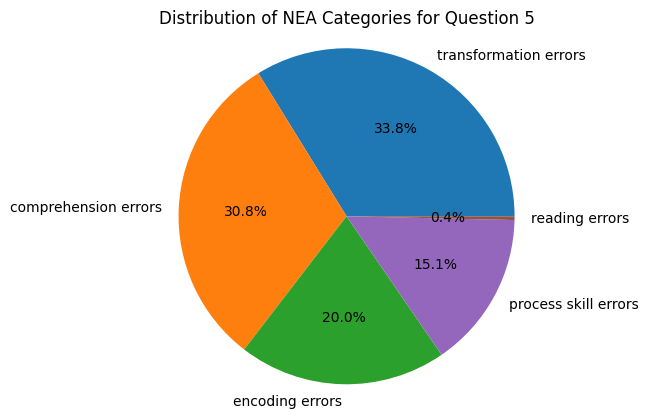

In [ ]:
# Prepare top 5 categories and group others
top_n = 4
top_cat_df = q5_error_cat_df.head(top_n)
others_pct = 100 - top_cat_df["Percentage"].sum()
labels = list(top_cat_df["Error Category"]) + ["reading errors"]
sizes = list(top_cat_df["Percentage"]) + [others_pct]

# Define colors excluding red
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']

# Plot pie chart
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors)
ax.axis('equal')
plt.title('Distribution of NEA Categories for Question 5')
plt.show()

# Common mistake for question 6

In [ ]:
# Re-import necessary libraries after environment reset
import pandas as pd
from collections import Counter



# Filter for Question 6 and drop missing error summaries
q6_errors = df[df["question"] == "Q. 6"]["error_summary"].dropna()

# Split and count individual error types
q6_error_types = q6_errors.str.split(", ").explode()
q6_error_counts = Counter(q6_error_types)

# Create DataFrame and calculate percentages
q6_error_df = pd.DataFrame(q6_error_counts.items(), columns=["Error Type", "Frequency"])
q6_error_df = q6_error_df.sort_values(by="Frequency", ascending=False).reset_index(drop=True)
total_q6_errors = q6_error_df["Frequency"].sum()
q6_error_df["Percentage"] = (q6_error_df["Frequency"] / total_q6_errors * 100).round(2)


q6_error_df

,Error Type,Frequency,Percentage
0,incorrect numerical value,461,28.44
1,conceptual misunderstanding,325,20.05
2,misinterpretation of notation,310,19.12
3,notational/formatting error,72,4.44
4,formatting error,33,2.04
...,...,...,...
202,incorrect format of the equation,1,0.06
203,algebraic manipulation error,1,0.06
204,interval misinterpretation,1,0.06
205,incorrect formatting,1,0.06


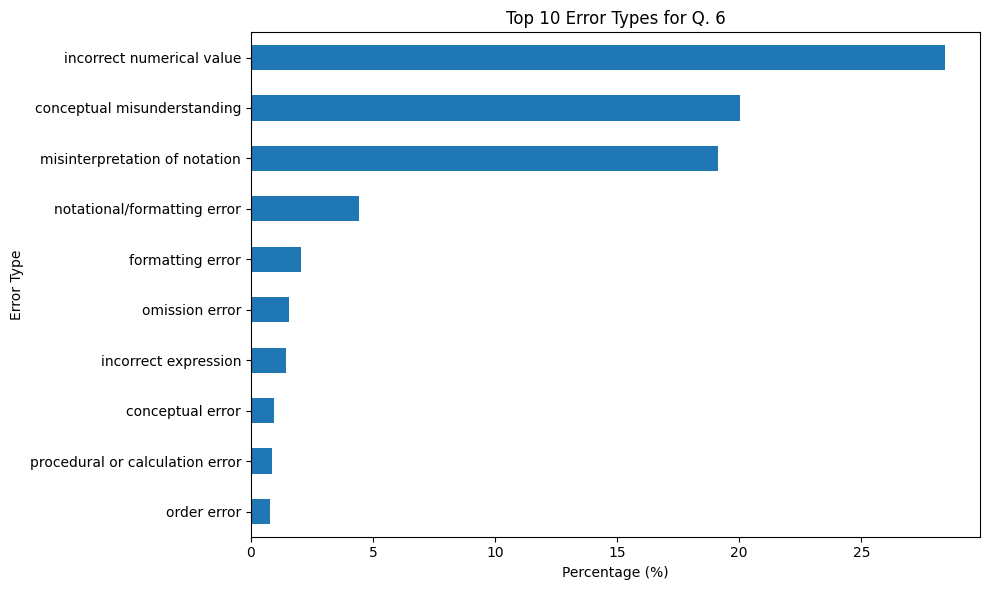

In [ ]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# ---- PARAMETERS ----
question = "Q. 6"      # which question to filter on
top_n = 10             # change this to any number you like

# ---- DATA PREP ----
errors = (
    df[df["question"] == question]
      ["error_summary"]
      .dropna()
      .str.split(", ")
      .explode()
)
counts = Counter(errors)
summary_df = (
    pd.DataFrame(counts.items(), columns=["Error Type", "Frequency"])
      .sort_values(by="Frequency", ascending=False)
      .reset_index(drop=True)
)
total = summary_df["Frequency"].sum()
summary_df["Percentage"] = (summary_df["Frequency"] / total * 100).round(2)

# ---- SELECT TOP N ----
top_df = summary_df.head(top_n)

# ---- PLOTTING ----
ax = top_df.plot(
    kind='barh',
    x='Error Type',
    y='Percentage',
    legend=False,
    figsize=(10, 6)
)
ax.invert_yaxis()  # largest at top
ax.set_xlabel("Percentage (%)")
ax.set_ylabel("Error Type")
ax.set_title(f"Top {len(top_df)} Error Types for {question}")
plt.tight_layout()
plt.show()


In [ ]:
# Filter for Question 6 and drop missing error categories
q6_error_cat = df[df["question"] == "Q. 6"]["error_category"].dropna()

# Split and count error categories
q6_error_cat_types = q6_error_cat.str.split(", ").explode()
q6_error_cat_counts = Counter(q6_error_cat_types)

# Create DataFrame and calculate percentages
q6_error_cat_df = pd.DataFrame(q6_error_cat_counts.items(), columns=["Error Category", "Frequency"])
q6_error_cat_df = q6_error_cat_df.sort_values(by="Frequency", ascending=False).reset_index(drop=True)
total_q6_cat_errors = q6_error_cat_df["Frequency"].sum()
q6_error_cat_df["Percentage"] = (q6_error_cat_df["Frequency"] / total_q6_cat_errors * 100).round(2)

q6_error_cat_df

,Error Category,Frequency,Percentage
0,transformation errors,457,33.24
1,comprehension errors,441,32.07
2,encoding errors,254,18.47
3,process skill errors,215,15.64
4,reading errors,7,0.51
5,No errors identified based on Newman's Error A...,1,0.07


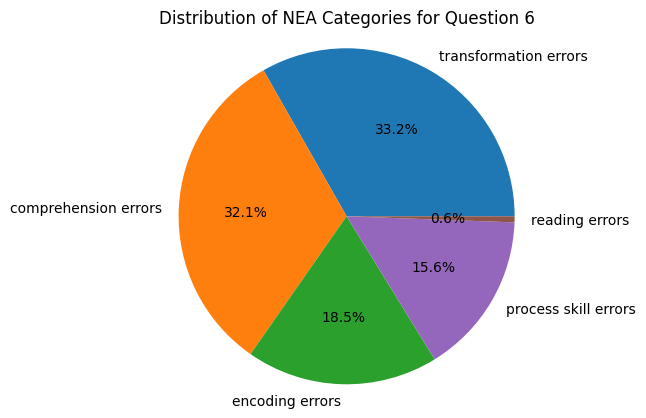

In [ ]:
# Prepare top 5 categories and group others
top_n = 4
top_cat_df = q6_error_cat_df.head(top_n)
others_pct = 100 - top_cat_df["Percentage"].sum()
labels = list(top_cat_df["Error Category"]) + ["reading errors"]
sizes = list(top_cat_df["Percentage"]) + [others_pct]

# Define colors excluding red
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']

# Plot pie chart
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors)
ax.axis('equal')
plt.title('Distribution of NEA Categories for Question 6')
plt.show()

# Common mistake question 1

In [ ]:
# Filter for Question 1 and drop missing error summaries
q1_errors = df[df["question"] == "Q. 1"]["error_summary"].dropna()

# Split and count individual error types
q1_error_types = q1_errors.str.split(", ").explode()
q1_error_counts = Counter(q1_error_types)

# Create DataFrame and calculate percentages
q1_error_df = pd.DataFrame(q1_error_counts.items(), columns=["Error Type", "Frequency"])
q1_error_df = q1_error_df.sort_values(by="Frequency", ascending=False).reset_index(drop=True)
total_q1_errors = q1_error_df["Frequency"].sum()
q1_error_df["Percentage"] = (q1_error_df["Frequency"] / total_q1_errors * 100).round(2)

q1_error_df

,Error Type,Frequency,Percentage
0,incorrect numerical value,348,51.94
1,conceptual misunderstanding,163,24.33
2,omission error,114,17.01
3,misinterpretation of notation,20,2.99
4,incorrect response,4,0.60
5,notational/formatting error,2,0.30
6,incomplete response,2,0.30
7,notation/formatting error,2,0.30
8,incorrect numerical interpretation,1,0.15
9,numerical/conceptual error,1,0.15


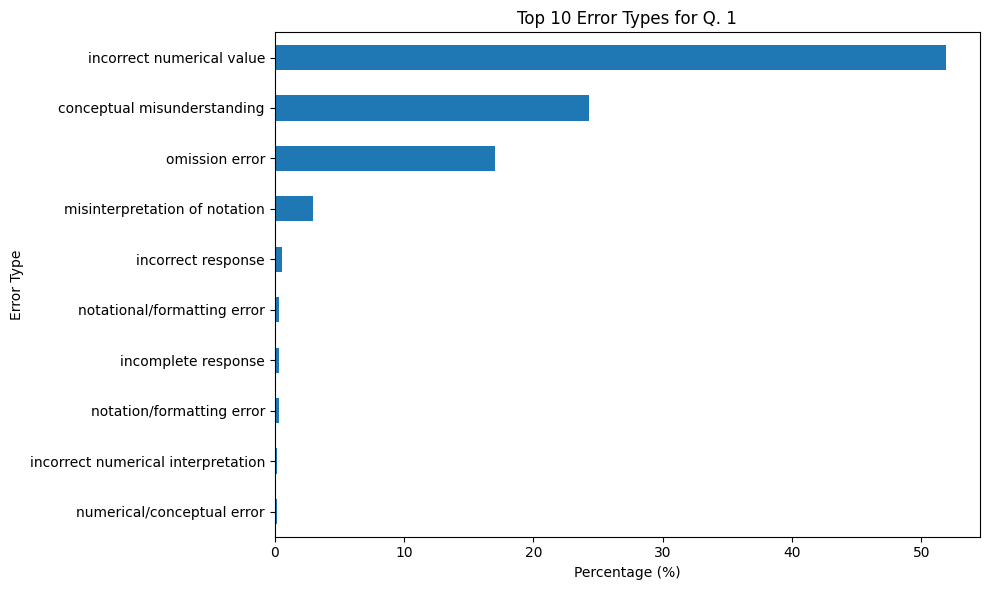

In [ ]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# ---- PARAMETERS ----
question = "Q. 1"      # which question to filter on
top_n = 10             # change this to any number you like

# ---- DATA PREP ----
errors = (
    df[df["question"] == question]
      ["error_summary"]
      .dropna()
      .str.split(", ")
      .explode()
)
counts = Counter(errors)
summary_df = (
    pd.DataFrame(counts.items(), columns=["Error Type", "Frequency"])
      .sort_values(by="Frequency", ascending=False)
      .reset_index(drop=True)
)
total = summary_df["Frequency"].sum()
summary_df["Percentage"] = (summary_df["Frequency"] / total * 100).round(2)

# ---- SELECT TOP N ----
top_df = summary_df.head(top_n)

# ---- PLOTTING ----
ax = top_df.plot(
    kind='barh',
    x='Error Type',
    y='Percentage',
    legend=False,
    figsize=(10, 6)
)
ax.invert_yaxis()  # largest at top
ax.set_xlabel("Percentage (%)")
ax.set_ylabel("Error Type")
ax.set_title(f"Top {len(top_df)} Error Types for {question}")
plt.tight_layout()
plt.show()


In [ ]:
# Filter for Question 1 and drop missing error categories
q1_error_cat = df[df["question"] == "Q. 1"]["error_category"].dropna()

# Split and count error categories
q1_error_cat_types = q1_error_cat.str.split(", ").explode()
q1_error_cat_counts = Counter(q1_error_cat_types)

# Create DataFrame and calculate percentages
q1_error_cat_df = pd.DataFrame(q1_error_cat_counts.items(), columns=["Error Category", "Frequency"])
q1_error_cat_df = q1_error_cat_df.sort_values(by="Frequency", ascending=False).reset_index(drop=True)
total_q1_cat_errors = q1_error_cat_df["Frequency"].sum()
q1_error_cat_df["Percentage"] = (q1_error_cat_df["Frequency"] / total_q1_cat_errors * 100).round(2)

q1_error_cat_df

,Error Category,Frequency,Percentage
0,comprehension errors,315,45.72
1,encoding errors,159,23.08
2,transformation errors,137,19.88
3,process skill errors,67,9.72
4,reading errors,7,1.02
5,No errors,2,0.29
6,Reading Errors,1,0.15
7,There are no errors in the student's response ...,1,0.15


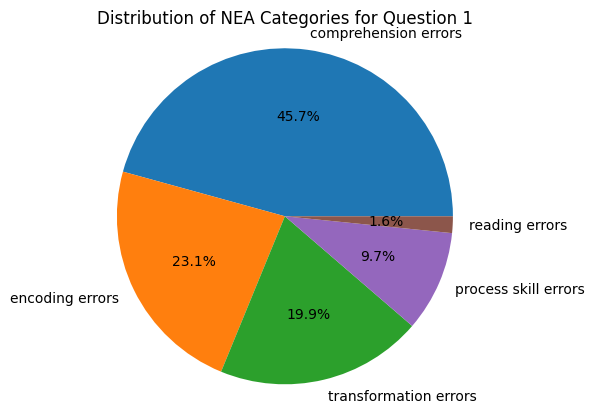

In [ ]:
# Prepare top 5 categories and group others
top_n = 4
top_cat_df = q1_error_cat_df.head(top_n)
others_pct = 100 - top_cat_df["Percentage"].sum()
labels = list(top_cat_df["Error Category"]) + ["reading errors"]
sizes = list(top_cat_df["Percentage"]) + [others_pct]

# Define colors excluding red
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']

# Plot pie chart
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors)
ax.axis('equal')
plt.title('Distribution of NEA Categories for Question 1')
plt.show()

# Common mistake question 2

In [ ]:
from collections import Counter
import pandas as pd

# Filter for Question 2 and drop missing error summaries
q2_errors = df[df["question"] == "Q. 2"]["error_summary"].dropna()

# Split and count individual error types
q2_error_types = q2_errors.str.split(", ").explode()
q2_error_counts = Counter(q2_error_types)

# Create DataFrame and calculate percentages
q2_error_df = pd.DataFrame(q2_error_counts.items(), columns=["Error Type", "Frequency"])
q2_error_df = q2_error_df.sort_values(by="Frequency", ascending=False).reset_index(drop=True)
total_q2_errors = q2_error_df["Frequency"].sum()
q2_error_df["Percentage"] = (q2_error_df["Frequency"] / total_q2_errors * 100).round(2)

# Display result
q2_error_df


,Error Type,Frequency,Percentage
0,incorrect numerical value,468,41.94
1,misinterpretation of notation,336,30.11
2,conceptual misunderstanding,162,14.52
3,omission error,70,6.27
4,notational/formatting error,20,1.79
5,procedural or calculation error,7,0.63
6,misinterpretation of expression,4,0.36
7,misinterpretation of interval notation,3,0.27
8,formatting error,3,0.27
9,incomplete response,3,0.27


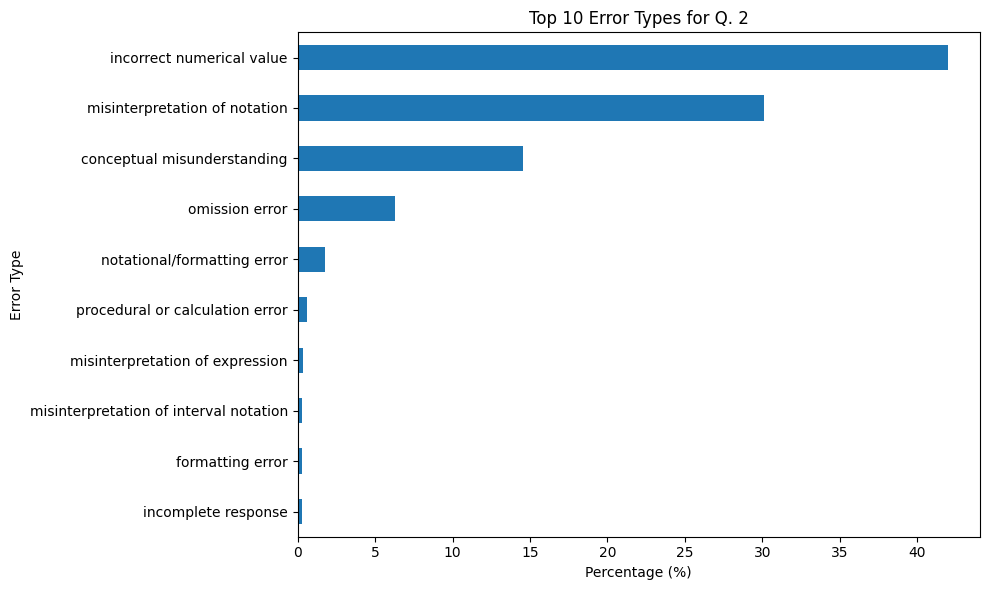

In [ ]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# ---- PARAMETERS ----
question = "Q. 2"      # which question to filter on
top_n = 10             # change this to any number you like

# ---- DATA PREP ----
errors = (
    df[df["question"] == question]
      ["error_summary"]
      .dropna()
      .str.split(", ")
      .explode()
)
counts = Counter(errors)
summary_df = (
    pd.DataFrame(counts.items(), columns=["Error Type", "Frequency"])
      .sort_values(by="Frequency", ascending=False)
      .reset_index(drop=True)
)
total = summary_df["Frequency"].sum()
summary_df["Percentage"] = (summary_df["Frequency"] / total * 100).round(2)

# ---- SELECT TOP N ----
top_df = summary_df.head(top_n)

# ---- PLOTTING ----
ax = top_df.plot(
    kind='barh',
    x='Error Type',
    y='Percentage',
    legend=False,
    figsize=(10, 6)
)
ax.invert_yaxis()  # largest at top
ax.set_xlabel("Percentage (%)")
ax.set_ylabel("Error Type")
ax.set_title(f"Top {len(top_df)} Error Types for {question}")
plt.tight_layout()
plt.show()


In [ ]:
# Filter for Question 2 and drop missing error categories
q2_error_cat = df[df["question"] == "Q. 2"]["error_category"].dropna()

# Split and count error categories
q2_error_cat_types = q2_error_cat.str.split(", ").explode()
q2_error_cat_counts = Counter(q2_error_cat_types)

# Create DataFrame and calculate percentages
q2_error_cat_df = pd.DataFrame(q2_error_cat_counts.items(), columns=["Error Category", "Frequency"])
q2_error_cat_df = q2_error_cat_df.sort_values(by="Frequency", ascending=False).reset_index(drop=True)
total_q2_cat_errors = q2_error_cat_df["Frequency"].sum()
q2_error_cat_df["Percentage"] = (q2_error_cat_df["Frequency"] / total_q2_cat_errors * 100).round(2)

q2_error_cat_df

,Error Category,Frequency,Percentage
0,transformation errors,411,36.89
1,comprehension errors,338,30.34
2,encoding errors,199,17.86
3,process skill errors,149,13.38
4,reading errors,11,0.99
5,Transformation Errors,2,0.18
6,Process Skill Errors,2,0.18
7,No errors,1,0.09
8,There are no errors evident in the analysis.,1,0.09


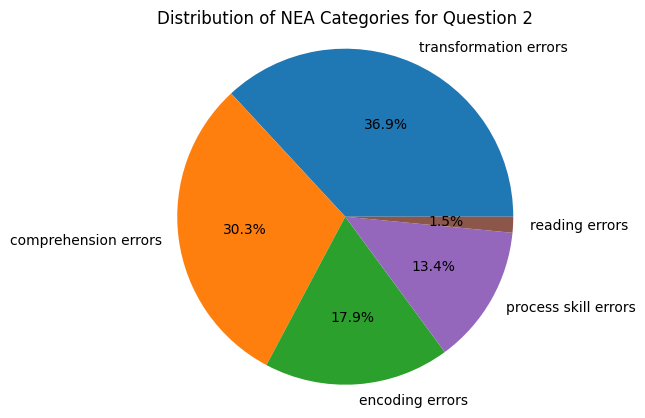

In [ ]:
# Prepare top 5 categories and group others
top_n = 4
top_cat_df = q2_error_cat_df.head(top_n)
others_pct = 100 - top_cat_df["Percentage"].sum()
labels = list(top_cat_df["Error Category"]) + ["reading errors"]
sizes = list(top_cat_df["Percentage"]) + [others_pct]

# Define colors excluding red
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']

# Plot pie chart
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors)
ax.axis('equal')
plt.title('Distribution of NEA Categories for Question 2')
plt.show()

# Task 2: Classify students into low, medium, high levels and their statistics

In [ ]:
df = pd.read_csv("/content/df_predicting_students_errors.csv")


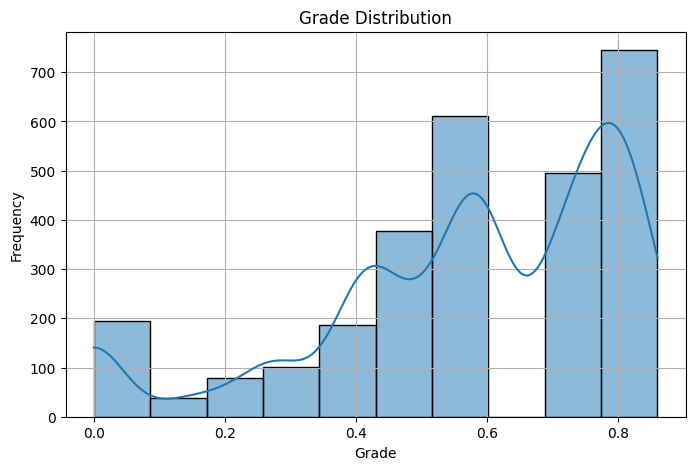

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df['grade'] = df['grade'].astype(float)
df['question'] = df['question'].str.strip()
df['error_summary'] = df['error_summary'].str.lower()

# Grade distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['grade'], bins=10, kde=True)
plt.title("Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Error typpes overview based on error_summary feature

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Clean and normalize the 'error_summary' column
df['error_summary_overview'] = (
    df['error_summary']
    .fillna("")
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Tokenize the comma-separated error types
vectorizer = CountVectorizer(tokenizer=lambda x: [e.strip() for e in x.split(',')])
X_errors = vectorizer.fit_transform(df['error_summary_overview'])

# Sum occurrences of each error type
error_counts = X_errors.sum(axis=0)
error_freq = pd.Series(error_counts.A1, index=vectorizer.get_feature_names_out()).sort_values(ascending=False)

# Convert to DataFrame for display
error_summary_Freq = error_freq.rename_axis("Error Type").reset_index(name="Frequency")

error_summary_Freq

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,Error Type,Frequency
0,incorrect numerical value,2162
1,conceptual misunderstanding,1219
2,misinterpretation of notation,1059
3,omission error,258
4,notational/formatting error,172
...,...,...
410,incorrect substitution of variables,1
411,incorrect solutions,1
412,incorrect solution type and interval misinterp...,1
413,incorrect solution set,1


In [ ]:
total_errors = error_summary_Freq["Frequency"].sum()
print(total_errors)


6031


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import numpy as np

df = pd.read_csv("/content/df_predicting_students_errors.csv")

# Step 1: Create performance levels
def categorize_grade(grade):
    if grade < 0.4:
        return 'Low'
    elif grade < 0.7:
        return 'Medium'
    else:
        return 'High'

df['performance_level'] = df['grade'].apply(categorize_grade)

# Step 2: Prepare text and numeric features
tfidf = TfidfVectorizer(max_features=100)  # limit features for performance
X_text = tfidf.fit_transform(df['error_summary'].fillna(""))

# Combine grade as numeric feature
X_combined = np.hstack((X_text.toarray(), df[['grade']].values))

# Target variable
le = LabelEncoder()
y = le.fit_transform(df['performance_level'])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

# Step 3: Train classifiers
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC()
}

# Fit models and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)

results


{'Random Forest': {'High': {'precision': 1.0,
   'recall': 1.0,
   'f1-score': 1.0,
   'support': 239.0},
  'Low': {'precision': 0.9871794871794872,
   'recall': 0.9871794871794872,
   'f1-score': 0.9871794871794872,
   'support': 78.0},
  'Medium': {'precision': 0.996,
   'recall': 0.996,
   'f1-score': 0.996,
   'support': 250.0},
  'accuracy': 0.9964726631393298,
  'macro avg': {'precision': 0.9943931623931624,
   'recall': 0.9943931623931624,
   'f1-score': 0.9943931623931624,
   'support': 567.0},
  'weighted avg': {'precision': 0.9964726631393298,
   'recall': 0.9964726631393298,
   'f1-score': 0.9964726631393298,
   'support': 567.0}},
 'Logistic Regression': {'High': {'precision': 0.9958333333333333,
   'recall': 1.0,
   'f1-score': 0.9979123173277662,
   'support': 239.0},
  'Low': {'precision': 1.0,
   'recall': 0.8076923076923077,
   'f1-score': 0.8936170212765957,
   'support': 78.0},
  'Medium': {'precision': 0.9431818181818182,
   'recall': 0.996,
   'f1-score': 0.9688715

In [ ]:
# Flatten the data into a list of rows
rows = []
for model, metrics in results.items():
    for label, scores in metrics.items():
        if isinstance(scores, dict):
            row = {
                "Model": model,
                "Class/Metric": label,
                "Precision": scores.get("precision"),
                "Recall": scores.get("recall"),
                "F1-score": scores.get("f1-score"),
                "Support": scores.get("support")
            }
            rows.append(row)
        elif label == "accuracy":
            rows.append({
                "Model": model,
                "Class/Metric": "accuracy",
                "Precision": None,
                "Recall": None,
                "F1-score": scores,
                "Support": None
            })

# Create the DataFrame
df_results = pd.DataFrame(rows)

df_results

,Model,Class/Metric,Precision,Recall,F1-score,Support
0,Random Forest,High,1.000000,1.000000,1.000000,239.0
1,Random Forest,Low,0.987179,0.987179,0.987179,78.0
2,Random Forest,Medium,0.996000,0.996000,0.996000,250.0
3,Random Forest,accuracy,NaN,NaN,0.996473,NaN
4,Random Forest,macro avg,0.994393,0.994393,0.994393,567.0
5,Random Forest,weighted avg,0.996473,0.996473,0.996473,567.0
6,Logistic Regression,High,0.995833,1.000000,0.997912,239.0
7,Logistic Regression,Low,1.000000,0.807692,0.893617,78.0
8,Logistic Regression,Medium,0.943182,0.996000,0.968872,250.0
9,Logistic Regression,accuracy,NaN,NaN,0.971781,NaN


In [ ]:
import pandas as pd

# Predict on the entire dataset using the trained Random Forest model
full_predictions = models["Random Forest"].predict(X_combined)
full_predicted_labels = le.inverse_transform(full_predictions)

# Add predictions to the original DataFrame as an ordered categorical
df['Predicted Performance Level'] = pd.Categorical(
    full_predicted_labels,
    categories=["High", "Medium", "Low"],
    ordered=True
)

# Now when you groupby, the categories will respect that order
stats = df.groupby('Predicted Performance Level')['grade'].describe()

# If you just want to see them in the specified order explicitly:
stats = stats.reindex(["High", "Medium", "Low"])

stats


<ipython-input-75-5356f1f23ca5>:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby('Predicted Performance Level')['grade'].describe()


,count,mean,std,min,25%,50%,75%,max
Predicted Performance Level,,,,,,,,
High,1240.0,0.778976,0.049093,0.71,0.75,0.80,0.80,0.86
Medium,1177.0,0.515208,0.077985,0.25,0.43,0.57,0.57,0.60
Low,414.0,0.129203,0.129340,0.00,0.00,0.14,0.25,0.50


#  Most common error types made by students in the Low performance group

In [ ]:
# Filter rows with predicted performance level as 'Low'
low_performance_df = df[df['Predicted Performance Level'] == 'Low']

# Display the first few rows (optional)
low_performance_df



,student_id,response,right_answer,question,seed_id,grade,llm_response,error_summary,error_category,performance_level,Predicted Performance Level
3,1,ans1: y=-8/5-8/5,ans1: y = -((8*x)/5)-8/5,Q. 4,163677917,0.00,"To analyze the student's error in mathematics,...","omission error, conceptual misunderstanding","comprehension errors, transformation errors",Low,Low
28,6,ans1: y=3*x+14,ans1: y = 3*x-14,Q. 4,2090009098,0.00,To categorize the type of error the student ma...,incorrect numerical value,encoding errors,Low,Low
34,7,ans1: y=-4*x+18,ans1: y = 66-16*x,Q. 4,316590787,0.00,To categorize the types of errors made by the ...,"incorrect numerical value, conceptual misunder...","comprehension errors, transformation errors",Low,Low
43,9,ans1: t/5 ans2: 25*t^2 ans3: 5*sin(theta)^3*...,ans1: -(t/5) ans2: 5*t^2 ans3: 0 ans4: 5*si...,Q. 3,1094247988,0.25,To categorize the types of errors made by the ...,"incorrect numerical value, conceptual misunder...","encoding errors, transformation errors, compre...",Low,Low
45,9,"ans1: 2*t/(3*t^2-2*t-2) ans2: (t=0,t=2,t=-1) ...","ans1: (2*t)/(3*t^2-2*t-2) ans2: [t = 2,t = -1...",Q. 6,11050265,0.29,To categorize the types of errors made by the ...,"notational/formatting error, conceptual misund...","transformation errors, comprehension errors, e...",Low,Low
...,...,...,...,...,...,...,...,...,...,...,...
2823,617,ans1: 4*t^2 ans2: 0 ans3: 6*cos(theta)^2 an...,ans1: -(t/4) ans2: t^2 ans3: 0 ans4: 6*sin(...,Q. 3,2018584510,0.00,To effectively categorize the types of errors ...,conceptual misunderstanding,"comprehension errors, transformation errors, p...",Low,Low
2824,617,"ans1: 2*t/(-8*t^3-9*t^2+2*t) ans2: [t=2,t=0,t...","ans1: (2*t)/(5*t^4-8*t^3-9*t^2) ans2: [t = 3,...",Q. 5,353452773,0.00,To categorize the types of errors made by the ...,"incorrect numerical value, conceptual misunder...","transformation errors, process skill errors, c...",Low,Low
2825,617,"ans1: 2*t/(4*t^3+6*t^2-6*t) ans2: [t=6,t=0,t=0]","ans1: (2*t)/(4*t^3+6*t^2-6*t) ans2: [t = -3,t...",Q. 6,1870045830,0.14,To categorize the types of errors made by the ...,"incorrect numerical value, conceptual misunder...",transformation errors,Low,Low
2829,618,"ans1: (2*t)/(5*t^4-8*t^3-9*t^3) ans2: [t=0,t=...","ans1: (2*t)/(5*t^4-8*t^3-9*t^2) ans2: [t = 3,...",Q. 5,353452773,0.14,Let's analyze the student's responses compared...,"misinterpretation of notation, incorrect numer...","comprehension errors, transformation errors, p...",Low,Low


In [ ]:
# Filter dataset to only include students predicted as "Low"
low_group_df = df[df['Predicted Performance Level'] == 'Low'].copy()

# Clean and normalize error summary text
low_group_df['error_summary_clean'] = (
    low_group_df['error_summary']
    .fillna("")
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Tokenize and count errors
vectorizer_low = CountVectorizer(tokenizer=lambda x: [e.strip() for e in x.split(',')])
X_errors_low = vectorizer_low.fit_transform(low_group_df['error_summary_clean'])

# Sum and sort frequencies
error_counts_low = X_errors_low.sum(axis=0)
error_freq_low = pd.Series(
    error_counts_low.A1, index=vectorizer_low.get_feature_names_out()
).sort_values(ascending=False)

# Prepare top 5 errors
top_5_errors_low = error_freq_low.head(5).reset_index()
top_5_errors_low.columns = ["Error Type", "Frequency"]

# Reference: full dataset error frequency (from error_summary_Freq)
top_5_errors_low["Total_Frequency"] = top_5_errors_low["Error Type"].map(
    error_summary_Freq.set_index("Error Type")["Frequency"]
)

# Compute percentage relative to total dataset frequency
top_5_errors_low["Percentage"] = (
    (top_5_errors_low["Frequency"] / top_5_errors_low["Total_Frequency"]) * 100
).round(2)

# Final table
top_5_errors_low


/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,Error Type,Frequency,Total_Frequency,Percentage
0,incorrect numerical value,316,2162,14.62
1,conceptual misunderstanding,305,1219,25.02
2,misinterpretation of notation,163,1059,15.39
3,omission error,42,258,16.28
4,sign error,30,69,43.48


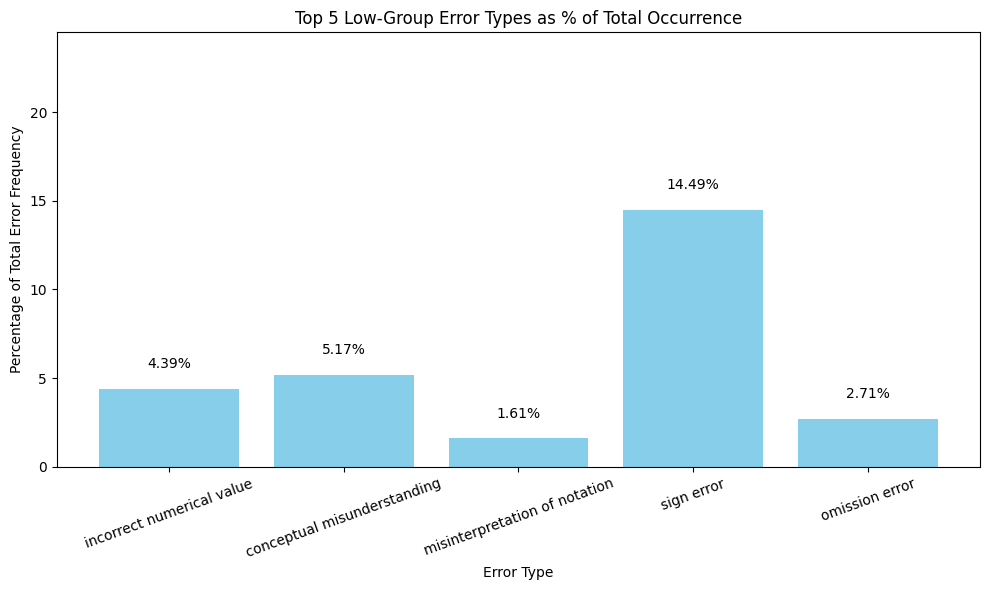

In [ ]:
import matplotlib.pyplot as plt

# Get top 5 most common errors in the Low group
top_5_errors = error_summary_df.head(5).copy()

# Get full dataset error frequencies (from earlier code)
# Assuming `error_summary_Freq` already exists
# Map each top 5 error to its full dataset frequency
top_5_errors['Total_Frequency'] = top_5_errors['Error Type'].map(
    error_summary_Freq.set_index('Error Type')['Frequency']
)

# Compute percentage relative to total error frequency across all students
top_5_errors['Percentage'] = (
    (top_5_errors['Frequency'] / top_5_errors['Total_Frequency']) * 100
).round(2)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(top_5_errors['Error Type'], top_5_errors['Percentage'], color='skyblue')

# Annotate bars
for bar, pct in zip(bars, top_5_errors['Percentage']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{pct}%', ha='center', va='bottom')

plt.title('Top 5 Low-Group Error Types as % of Total Occurrence')
plt.ylabel('Percentage of Total Error Frequency')
plt.xlabel('Error Type')
plt.ylim(0, max(top_5_errors['Percentage']) + 10)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


#  Most common error types made by students in the Medium performance group

In [ ]:
# Filter dataset to only include students predicted as "Medium"
medium_group_df = df[df['Predicted Performance Level'] == 'Medium'].copy()

# Clean and normalize error summary text
medium_group_df['error_summary_clean'] = (
    medium_group_df['error_summary']
    .fillna("")
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Tokenize and count errors
vectorizer_medium = CountVectorizer(tokenizer=lambda x: [e.strip() for e in x.split(',')])
X_errors_medium = vectorizer_medium.fit_transform(medium_group_df['error_summary_clean'])

# Sum and sort frequencies
error_counts_medium = X_errors_medium.sum(axis=0)
error_freq_medium = pd.Series(
    error_counts_medium.A1, index=vectorizer_medium.get_feature_names_out()
).sort_values(ascending=False)

# Prepare top 5 errors
top_5_errors_medium = error_freq_medium.head(5).reset_index()
top_5_errors_medium.columns = ["Error Type", "Frequency"]

# Reference: full dataset error frequency (from earlier)
# Make sure error_summary_Freq is already computed from full dataset
top_5_errors_medium["Total_Frequency"] = top_5_errors_medium["Error Type"].map(
    error_summary_Freq.set_index("Error Type")["Frequency"]
)

# Compute % of each error type in Medium group relative to total frequency
top_5_errors_medium["Percentage"] = (
    (top_5_errors_medium["Frequency"] / top_5_errors_medium["Total_Frequency"]) * 100
).round(2)

# Final table
top_5_errors_medium


/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,Error Type,Frequency,Total_Frequency,Percentage
0,incorrect numerical value,1037,2162,47.96
1,conceptual misunderstanding,598,1219,49.06
2,misinterpretation of notation,556,1059,52.50
3,omission error,113,258,43.80
4,notational/formatting error,87,172,50.58


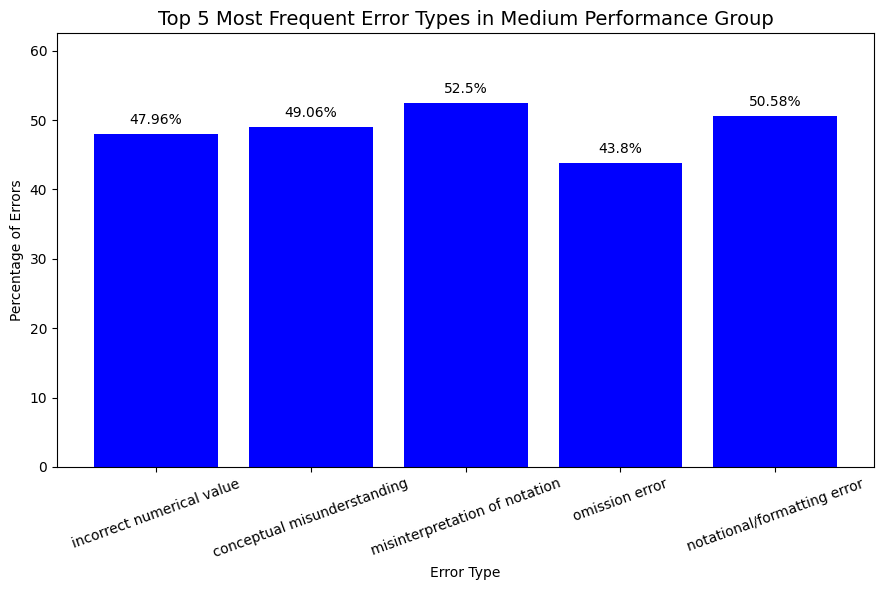

In [ ]:
# Plot the same chart but with yellow bars
plt.figure(figsize=(9, 6))
bars = plt.bar(top_5_errors_medium['Error Type'], top_5_errors_medium['Percentage'], color='blue')

# Annotate bars with percentage values
for bar, pct in zip(bars, top_5_errors_medium['Percentage']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{pct}%', ha='center', va='bottom')

plt.title('Top 5 Most Frequent Error Types in Medium Performance Group', fontsize=14)
plt.ylabel('Percentage of Errors')
plt.xlabel('Error Type')
plt.ylim(0, max(top_5_errors_medium['Percentage']) + 10)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# Most common error types made by students in the High performance group

In [ ]:
import matplotlib.pyplot as plt

# Filter dataset to only include students predicted as "High"
high_group_df = df[df['Predicted Performance Level'] == 'High'].copy()

# Clean and normalize error summary text
high_group_df['error_summary_clean'] = (
    high_group_df['error_summary']
    .fillna("")
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Tokenize and count errors
vectorizer_high = CountVectorizer(tokenizer=lambda x: [e.strip() for e in x.split(',')])
X_errors_high = vectorizer_high.fit_transform(high_group_df['error_summary_clean'])

# Sum and sort frequencies
error_counts_high = X_errors_high.sum(axis=0)
error_freq_high = pd.Series(
    error_counts_high.A1, index=vectorizer_high.get_feature_names_out()
).sort_values(ascending=False)

# Prepare top 5 error types
top_5_errors_high = error_freq_high.head(5).reset_index()
top_5_errors_high.columns = ["Error Type", "Frequency"]

# Map total frequency from full dataset
top_5_errors_high["Total_Frequency"] = top_5_errors_high["Error Type"].map(
    error_summary_Freq.set_index("Error Type")["Frequency"]
)

# Compute global percentage
top_5_errors_high["Percentage"] = (
    (top_5_errors_high["Frequency"] / top_5_errors_high["Total_Frequency"]) * 100
).round(2)

top_5_errors_high

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,Error Type,Frequency,Total_Frequency,Percentage
0,incorrect numerical value,809,2162,37.42
1,misinterpretation of notation,340,1059,32.11
2,conceptual misunderstanding,316,1219,25.92
3,omission error,103,258,39.92
4,notational/formatting error,67,172,38.95


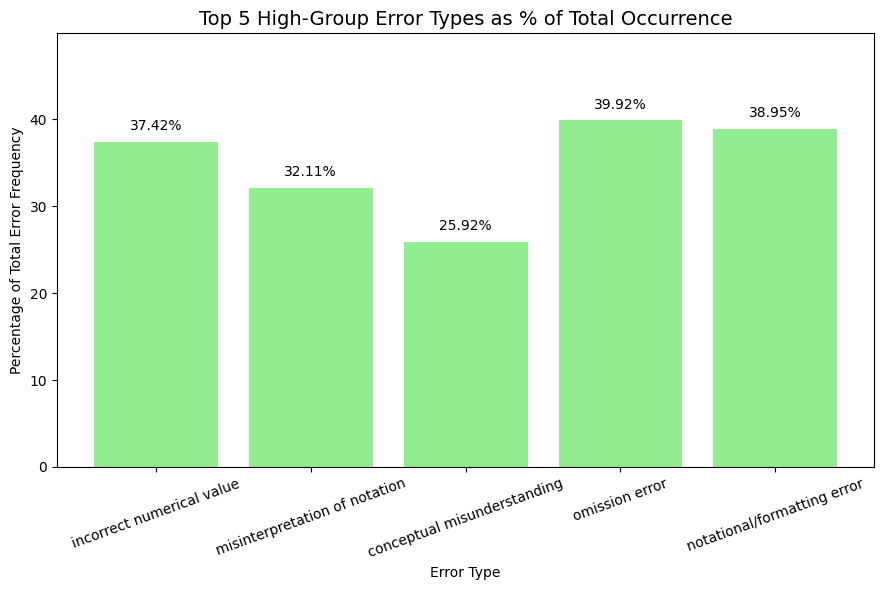

In [ ]:
# Plot
plt.figure(figsize=(9, 6))
bars = plt.bar(top_5_errors_high['Error Type'], top_5_errors_high['Percentage'], color='lightgreen')

# Annotate bars
for bar, pct in zip(bars, top_5_errors_high['Percentage']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{pct}%', ha='center', va='bottom')

plt.title('Top 5 High-Group Error Types as % of Total Occurrence', fontsize=14)
plt.ylabel('Percentage of Total Error Frequency')
plt.xlabel('Error Type')
plt.ylim(0, max(top_5_errors_high['Percentage']) + 10)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# Comparison of Common Error Types by Performance Level


# Expressed the charts in percentage


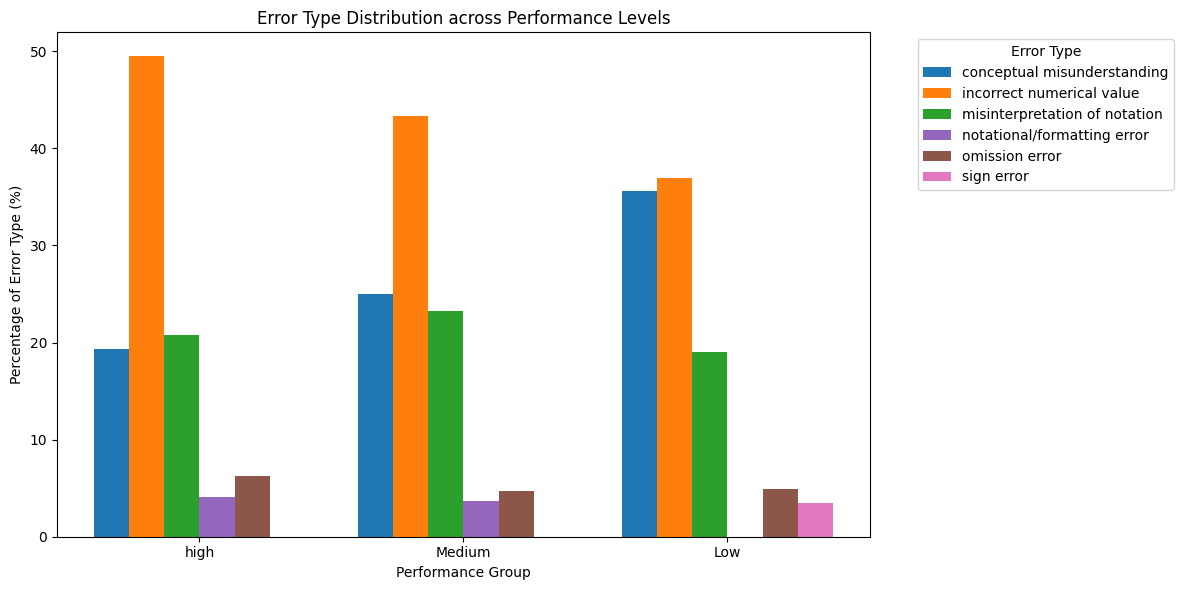

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Helper to normalize the “High” label to lowercase “high” ---
def normalize_group_name(df, name):
    return df.assign(Group=name.lower() if name == "High" else name)

# --- Step 1: Combine all groups into one DataFrame with normalized labels ---
df = pd.concat([
    normalize_group_name(top_5_errors_low,    "Low"),
    normalize_group_name(top_5_errors_medium, "Medium"),
    normalize_group_name(top_5_errors_high,   "High"),
], ignore_index=True)

# --- Step 2: Drop any “Red” error types globally ---
df = df[df["Error Type"] != "Red"]

# --- Step 3: Pivot to get a matrix of frequencies (missing → 0) ---
error_df = df.pivot_table(
    index="Group",
    columns="Error Type",
    values="Frequency",
    fill_value=0
)

# --- Step 4: Convert frequencies to row‑wise percentages ---
error_pct = error_df.div(error_df.sum(axis=1), axis=0) * 100

# --- Step 5: Reindex rows to your desired order ---
desired_order = ['high', 'Medium', 'Low']
error_pct = error_pct.reindex(desired_order)

# --- Step 6: Define a non‑red color palette ---
color_list = [
    "#1f77b4",  # muted blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # olive
    "#17becf",  # cyan
]

# Map each error type to one of the non‑red colors
errors = error_pct.columns.tolist()
color_map = dict(zip(errors, color_list[:len(errors)]))

# --- Step 7: Plot grouped bar chart using the custom colors ---
groups = error_pct.index.tolist()
x = np.arange(len(groups))
width = 0.8 / len(errors)

plt.figure(figsize=(12, 6))
for i, err in enumerate(errors):
    plt.bar(
        x + i * width,
        error_pct[err],
        width=width,
        label=err,
        color=color_map[err]
    )

plt.xlabel("Performance Group")
plt.ylabel("Percentage of Error Type (%)")
plt.title("Error Type Distribution across Performance Levels")
plt.xticks(x + width * (len(errors) - 1) / 2, groups)
plt.legend(title="Error Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# Task 3: Feature importance plot to see what features influenced the classification most

# For Low performance level

In [ ]:
# Step 1: Install SHAP
!pip install shap

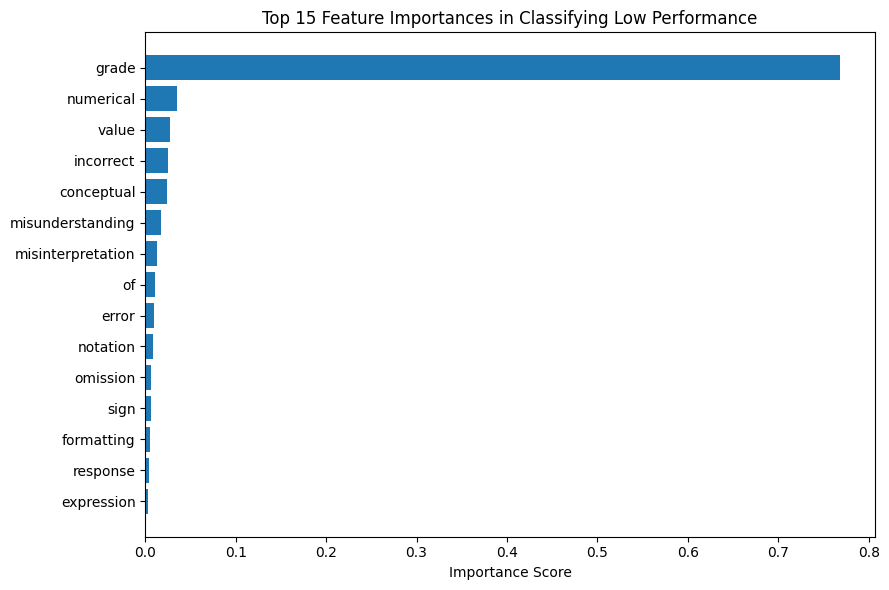

In [ ]:
# Re-import necessary libraries for model and vectorization
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Reload dataset
file_path = "/content/df_predicting_students_errors.csv"
df = pd.read_csv(file_path)

# Step 1: Categorize grades
def categorize_grade(grade):
    if grade < 0.4:
        return 'Low'
    elif grade < 0.7:
        return 'Medium'
    else:
        return 'High'

df['performance_level'] = df['grade'].apply(categorize_grade)

# Step 2: TF-IDF and feature matrix
tfidf = TfidfVectorizer(max_features=100)
X_text = tfidf.fit_transform(df['error_summary'].fillna(""))

# Combine with grade feature
X_combined = np.hstack((X_text.toarray(), df[['grade']].values))

# Target variable
le = LabelEncoder()
y = le.fit_transform(df['performance_level'])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

# Train Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Get index of 'Low' class
low_index = list(le.classes_).index('Low')

# Extract feature importances
feature_names = list(tfidf.get_feature_names_out()) + ['grade']
importances = rf_model.feature_importances_

# Focus: show importances influencing prediction of 'Low' (not specific to SHAP)
top_indices = np.argsort(importances)[-15:][::-1]  # Top 15 features

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
plt.barh(range(len(top_indices)), importances[top_indices])
plt.yticks(range(len(top_indices)), [feature_names[i] for i in top_indices])
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importances in Classifying Low Performance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
# Get top 15 feature importances and calculate their percentages
top_features = [(feature_names[i], importances[i]) for i in top_indices]
top_features_df = pd.DataFrame(top_features, columns=["Feature", "Importance"])

# Convert to percentage
top_features_df["Percentage"] = (top_features_df["Importance"] / top_features_df["Importance"].sum() * 100).round(2)

top_features_df

,Feature,Importance,Percentage
0,grade,0.768429,79.81
1,numerical,0.035209,3.66
2,value,0.027047,2.81
3,incorrect,0.024946,2.59
4,conceptual,0.023705,2.46
5,misunderstanding,0.017734,1.84
6,misinterpretation,0.013070,1.36
7,of,0.010572,1.10
8,error,0.009279,0.96
9,notation,0.008872,0.92


# For medium performance level

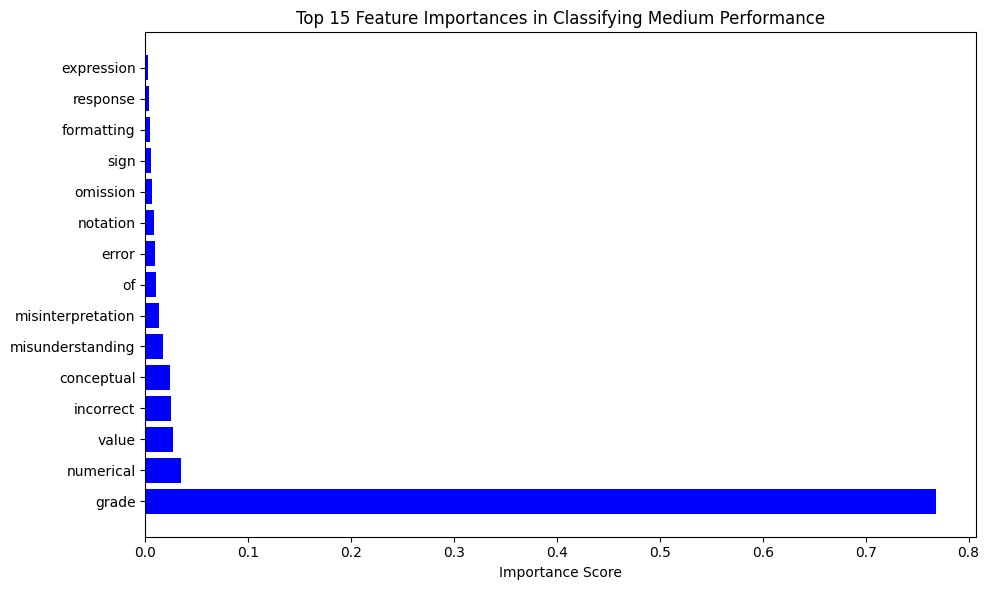

In [ ]:
# Assuming you already trained `rf_model` and used TF-IDF + grade as combined features
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from Random Forest
importances = rf_model.feature_importances_

# Get feature names (TF-IDF terms + 'grade' column)
feature_names = tfidf.get_feature_names_out().tolist() + ['grade']

# Get top 15 most important features (you can change this if needed)
top_indices_medium = np.argsort(importances)[-15:]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_indices_medium)), importances[top_indices_medium], color='blue')
plt.yticks(range(len(top_indices_medium)), [feature_names[i] for i in top_indices_medium])
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importances in Classifying Medium Performance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
# Get top 15 feature importances for medium classification and calculate their percentages
top_features_medium = [(feature_names[i], importances[i]) for i in top_indices_medium]
top_features_df_medium = pd.DataFrame(top_features_medium, columns=["Feature", "Importance"])

# Convert to percentage
top_features_df_medium["Percentage"] = (top_features_df_medium["Importance"] / top_features_df_medium["Importance"].sum() * 100).round(2)

top_features_df_medium

,Feature,Importance,Percentage
0,response,0.003836,0.40
1,expression,0.003150,0.33
2,formatting,0.004821,0.50
3,sign,0.005998,0.62
4,omission,0.006152,0.64
5,error,0.009279,0.96
6,notation,0.008872,0.92
7,misunderstanding,0.017734,1.84
8,of,0.010572,1.10
9,misinterpretation,0.013070,1.36


# Feature importance for High performance group

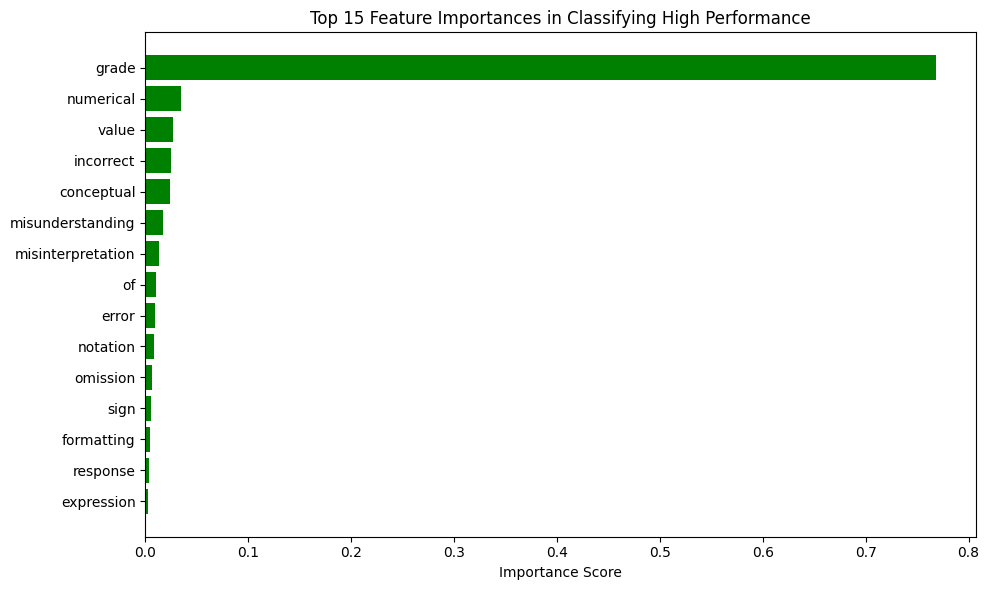

In [ ]:
# Get class index for 'High'
high_index = list(le.classes_).index('High')

# Get top 15 overall features (same logic as other groups)
top_indices_high = np.argsort(importances)[-15:][::-1]

# Plot feature importances for high performance in green
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_indices_high)), importances[top_indices_high], color='green')
plt.yticks(range(len(top_indices_high)), [feature_names[i] for i in top_indices_high])
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importances in Classifying High Performance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
